# Data Exploration & Feature Engineering

Explore the pre-cleaned site data and engineer features for model training.

**Input:** `site_aggregated_precleaned.parquet` — 57,675 sites × 102 columns  
**Output:** `site_training_data.parquet` — ~26K Active sites with log transforms, one-hot encoded flags, and binned categoricals

In [13]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Project paths
PROJECT_ROOT = Path('.').resolve()
DATA_INPUT = PROJECT_ROOT / 'data' / 'input'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/home/gkdev/geospatial


## 1. The Data Landscape

| File | Size | Description |
|------|------|-------------|
| `site_scores_revenue_and_diagnostics.csv` | 927 MB | Monthly records: 1.4M rows × 94 cols |
| `nearest_site_distances.csv` | 6.5 MB | Distance to nearest competing site |
| `site_interstate_distances.csv` | 3.8 MB | Distance to nearest interstate |
| `site_kroger_distances.csv` | 2.7 MB | Distance to nearest Kroger |
| `site_mcdonalds_distances.csv` | 2.8 MB | Distance to nearest McDonald's |
| `site_walmart_distances.csv` | 2.8 MB | Distance to nearest Walmart |
| `site_target_distances.csv` | 2.8 MB | Distance to nearest Target |

In [14]:
# Load the pre-cleaned site data (all statuses, 102 columns)
df = pl.read_parquet(DATA_PROCESSED / 'site_aggregated_precleaned.parquet')
print(f'Pre-cleaned data: {df.shape[0]:,} sites \u00d7 {df.shape[1]} columns')
print(f'\nColumn types:')
print(f'  Float:       {len([c for c in df.columns if df[c].dtype in [pl.Float64, pl.Float32]])}')
print(f'  Integer:     {len([c for c in df.columns if df[c].dtype in [pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt32]])}')
print(f'  String:      {len([c for c in df.columns if df[c].dtype == pl.Utf8])}')
print(f'  RS momentum: {len([c for c in df.columns if c.startswith("rs_")])}')
print(f'\nStatus distribution:')
for row in df.group_by('status').len().sort('len', descending=True).iter_rows(named=True):
    pct = row['len'] / len(df) * 100
    print(f'  {row["status"]:30s} {row["len"]:6,} ({pct:.1f}%)')

Pre-cleaned data: 57,675 sites × 102 columns

Column types:
  Float:       36
  Integer:     7
  String:      27
  RS momentum: 12

Status distribution:
  Active                         26,101 (45.3%)
  Temporarily Deactivated        23,374 (40.5%)
  Awaiting Installation           4,417 (7.7%)
  Deactivated                     3,094 (5.4%)
  Awaiting Reactivation             627 (1.1%)
  Cancelled                          60 (0.1%)
  Awaiting Deactivation               2 (0.0%)


## 2. Revenue Distribution

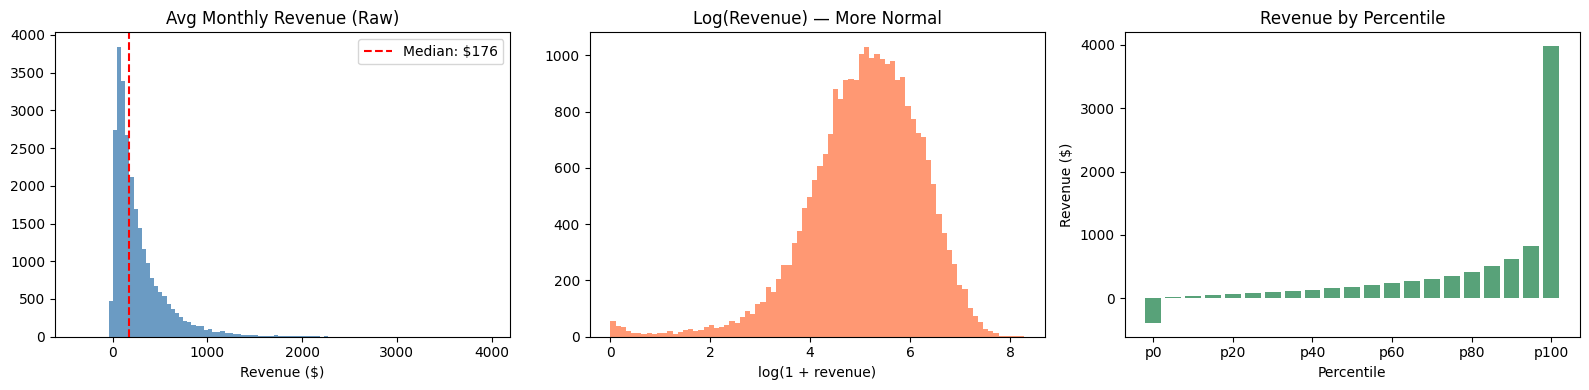

Active sites: 26,101
Revenue stats: min=$-391, median=$176, mean=$268, p90=$613, max=$3,979


In [25]:
# Filter to Active sites for revenue analysis
active = df.filter(pl.col('status') == 'Active')
revenue = active['avg_monthly_revenue'].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw distribution
axes[0].hist(revenue, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Avg Monthly Revenue (Raw)')
axes[0].set_xlabel('Revenue ($)')
axes[0].axvline(np.median(revenue), color='red', linestyle='--', label=f'Median: ${np.median(revenue):,.0f}')
axes[0].legend()

# Log distribution
log_rev = np.log1p(revenue[revenue > 0])
axes[1].hist(log_rev, bins=80, color='coral', edgecolor='none', alpha=0.8)
axes[1].set_title('Log(Revenue) \u2014 More Normal')
axes[1].set_xlabel('log(1 + revenue)')

# Percentile view
pcts = np.percentile(revenue, np.arange(0, 101, 5))
axes[2].bar(range(len(pcts)), pcts, color='seagreen', alpha=0.8)
axes[2].set_title('Revenue by Percentile')
axes[2].set_xlabel('Percentile')
axes[2].set_ylabel('Revenue ($)')
axes[2].set_xticks(range(0, len(pcts), 4))
axes[2].set_xticklabels([f'p{i}' for i in range(0, 101, 20)])

plt.tight_layout()
plt.show()

print(f'Active sites: {len(active):,}')
print(f'Revenue stats: min=${revenue.min():,.0f}, median=${np.median(revenue):,.0f}, '
      f'mean=${revenue.mean():,.0f}, p90=${np.percentile(revenue, 90):,.0f}, max=${revenue.max():,.0f}')

## 3. Feature Engineering Highlights

### Relative Strength (Momentum Indicators)
Compares recent performance to historical average — values > 1.0 indicate upward trend.

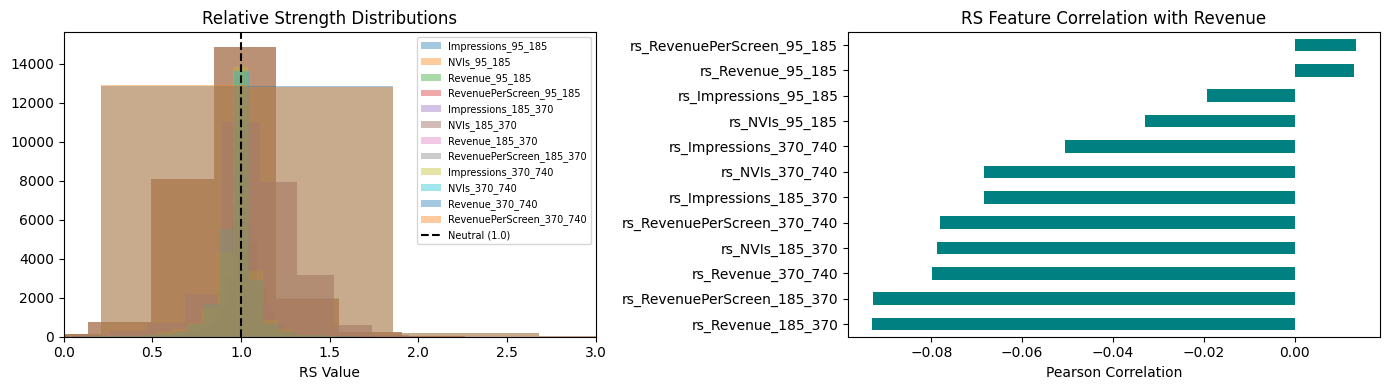

In [16]:
# Relative strength distribution and feature correlation with revenue
rs_cols = [c for c in df.columns if c.startswith('rs_')]
active_for_rs = df.filter(pl.col('status') == 'Active')
rs_data = active_for_rs.select(rs_cols).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# RS distribution
for col in rs_cols:
    axes[0].hist(rs_data[col].dropna(), bins=50, alpha=0.4, label=col.replace('rs_', ''))
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='Neutral (1.0)')
axes[0].set_title('Relative Strength Distributions')
axes[0].set_xlabel('RS Value')
axes[0].legend(fontsize=7)
axes[0].set_xlim(0, 3)

# RS correlation with revenue
corr_data = active_for_rs.select(rs_cols + ['avg_monthly_revenue']).to_pandas().corr()['avg_monthly_revenue'].drop('avg_monthly_revenue')
corr_data.sort_values().plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('RS Feature Correlation with Revenue')
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

### Geospatial Distance Features
Distances to key landmarks (interstate, Kroger, McDonald's, Walmart, Target).

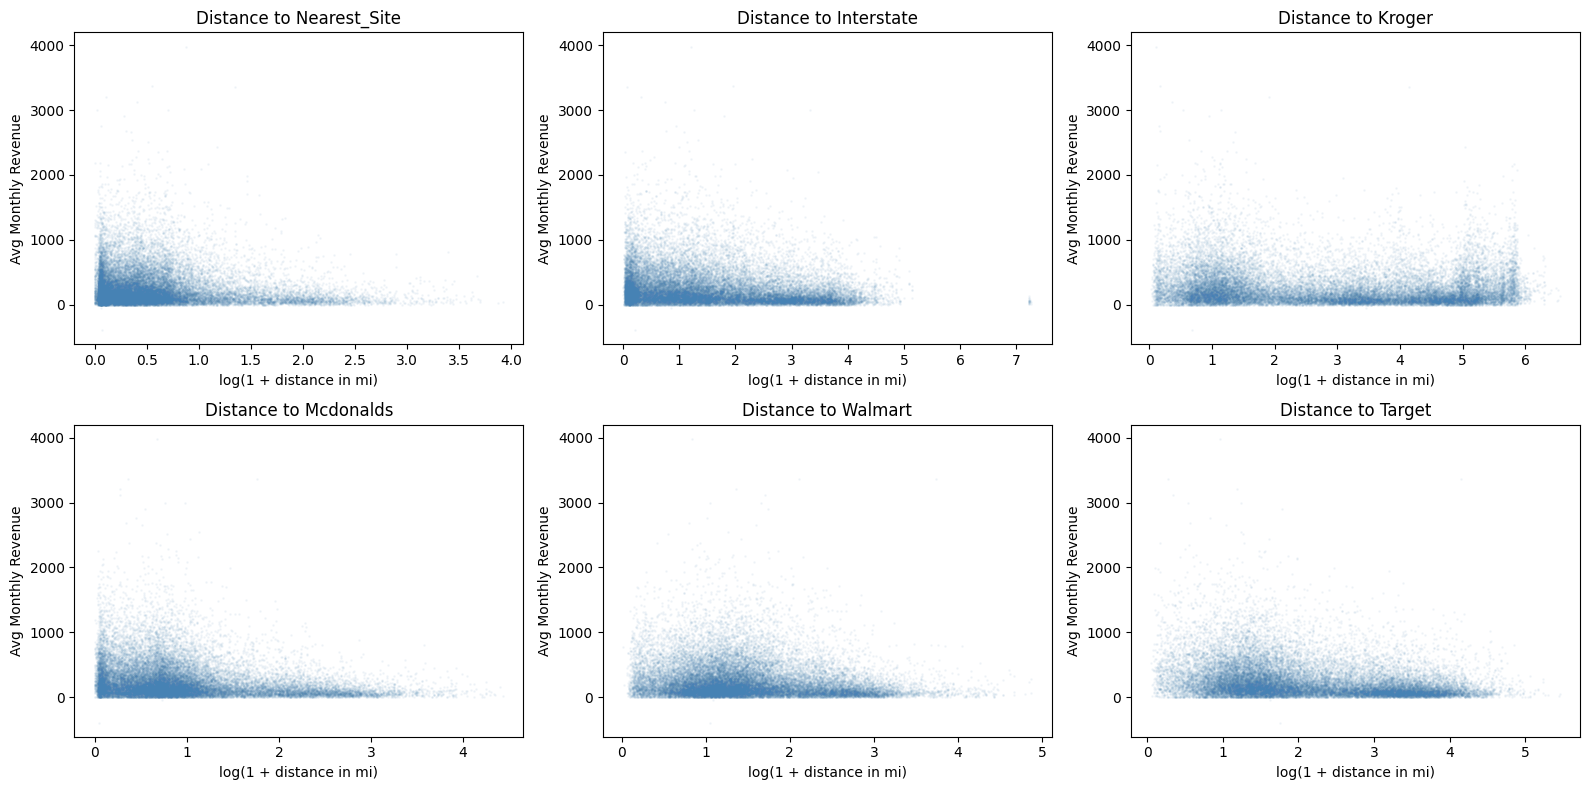

In [17]:
# Scatter sites average monthly revenue over distance metrics
dist_cols = [c for c in df.columns if c.startswith('min_distance_to_')]
active_for_dist = df.filter(pl.col('status') == 'Active')
dist_data = active_for_dist.select(dist_cols + ['avg_monthly_revenue']).to_pandas()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(dist_cols):
    if i < len(axes):
        label = col.replace('min_distance_to_', '').replace('_mi', '')
        axes[i].scatter(np.log1p(dist_data[col]), dist_data['avg_monthly_revenue'],
                       alpha=0.05, s=1, color='steelblue')
        axes[i].set_title(f'Distance to {label.title()}')
        axes[i].set_xlabel(f'log(1 + distance in mi)')
        axes[i].set_ylabel('Avg Monthly Revenue')

# Hide extra subplots
for j in range(len(dist_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [18]:
# Summary statistics for the pre-cleaned dataset
active = df.filter(pl.col('status') == 'Active')
print('=== Pre-cleaned Dataset Summary ===')
print(f'Total sites: {df.shape[0]:,}')
print(f'Active sites: {len(active):,}')
print(f'Columns: {df.shape[1]}')
print(f'\nActive months: median={active["active_months"].median():.0f}, '
      f'mean={active["active_months"].mean():.1f}')
print(f'Avg monthly revenue (Active): median=${active["avg_monthly_revenue"].median():,.0f}, '
      f'mean=${active["avg_monthly_revenue"].mean():,.0f}')

# Network distribution
print(f'\nNetwork distribution (Active):')
for row in active.group_by('network').len().sort('len', descending=True).head(5).iter_rows(named=True):
    print(f'  {row["network"]}: {row["len"]:,} sites')

=== Pre-cleaned Dataset Summary ===
Total sites: 57,675
Active sites: 26,101
Columns: 102

Active months: median=44, mean=35.1
Avg monthly revenue (Active): median=$176, mean=$268

Network distribution (Active):
  Gilbarco: 18,212 sites
  Dover: 5,111 sites
  Speedway: 2,760 sites
  Wayne: 18 sites


---
## 4. Prepare Training Dataset

Transform the pre-cleaned data into ML-ready format:
1. Filter to **Active sites only**
2. Remove negative revenue records
3. Drop geographic identifiers (state, county, dma, zip)
4. **Bin high-cardinality categoricals** (retailer → top 30 + Other)
5. **Log-transform** numeric features
6. **One-hot encode** capability and restriction flags

In [19]:
# Filter to active sites, remove negative revenue, drop geographic identifiers
train_df = df.clone()

# 4a. Filter to Active sites only
original_count = len(train_df)
train_df = train_df.filter(pl.col('status') == 'Active')
print(f'Filtered to Active sites: {len(train_df):,} (from {original_count:,})')

# 4b. Remove negative revenue records
before = len(train_df)
train_df = train_df.filter(pl.col('total_revenue') >= 0)
print(f'Removed {before - len(train_df):,} negative revenue records: {len(train_df):,} remaining')

# 4c. Drop geographic identifiers
geo_cols_to_drop = ['state', 'county', 'dma', 'zip', 'zip_4']
existing_geo_cols = [c for c in geo_cols_to_drop if c in train_df.columns]
train_df = train_df.drop(existing_geo_cols)
print(f'Dropped geographic identifiers: {existing_geo_cols}')

Filtered to Active sites: 26,101 (from 57,675)
Removed 2 negative revenue records: 26,099 remaining
Dropped geographic identifiers: ['state', 'county', 'dma', 'zip']


In [20]:
# Bin high-cardinality categorical features
def bin_high_cardinality(df: pl.DataFrame, column: str, top_n: int = 30) -> pl.DataFrame:
    """Keep top N values, replace the rest with 'Other'."""
    if column not in df.columns:
        return df
    value_counts = df[column].value_counts().sort('count', descending=True)
    top_values = value_counts[column].head(top_n).to_list()
    original_unique = df[column].n_unique()
    df = df.with_columns(
        pl.when(pl.col(column).is_in(top_values))
        .then(pl.col(column))
        .otherwise(pl.lit('Other'))
        .alias(column)
    )
    new_unique = df[column].n_unique()
    print(f'  Binned "{column}": {original_unique:,} → {new_unique} categories (top {top_n} + Other)')
    return df

train_df = bin_high_cardinality(train_df, column='retailer', top_n=30)
train_df = bin_high_cardinality(train_df, column='brand_c_store', top_n=30)
train_df = bin_high_cardinality(train_df, column='brand_fuel', top_n=10)

  Binned "retailer": 10,557 → 31 categories (top 30 + Other)
  Binned "brand_c_store": 8,711 → 31 categories (top 30 + Other)
  Binned "brand_fuel": 145 → 11 categories (top 10 + Other)


In [21]:
# Add log transformations to numeric features
# Sign-preserving: sign(x) * log(1 + |x|) for signed types
numeric_cols_to_log = [
    'total_revenue', 'total_monthly_impressions', 'total_monthly_nvis',
    'total_monthly_impressions_per_screen', 'total_monthly_nvis_per_screen',
    'total_monthly_revenue_per_screen',
    'min_distance_to_nearest_site_mi', 'min_distance_to_interstate_mi',
    'min_distance_to_kroger_mi', 'min_distance_to_mcdonalds_mi',
    'min_distance_to_walmart_mi', 'min_distance_to_target_mi',
    'avg_household_income',
]

log_count = 0
for col in numeric_cols_to_log:
    if col in train_df.columns:
        col_dtype = train_df[col].dtype
        if col_dtype in [pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64]:
            train_df = train_df.with_columns(
                (pl.col(col).cast(pl.Float64) + 1).log().alias(f'log_{col}')
            )
        else:
            train_df = train_df.with_columns(
                pl.when(pl.col(col).cast(pl.Float64) >= 0)
                .then((pl.col(col).cast(pl.Float64) + 1).log())
                .otherwise(-(-pl.col(col).cast(pl.Float64) + 1).log())
                .alias(f'log_{col}')
            )
        log_count += 1

print(f'Added {log_count} log-transformed columns')

Added 13 log-transformed columns


In [22]:
# One-hot encode capability (c_*) and restriction (r_*) flags
capability_cols = [c for c in train_df.columns if c.startswith('c_')]
restriction_cols = [c for c in train_df.columns if c.startswith('r_')]
other_flags = ['schedule_site', 'sellable_site']
all_flag_cols = capability_cols + restriction_cols + other_flags

encoded_count = 0
for col in all_flag_cols:
    if col not in train_df.columns:
        continue
    col_dtype = train_df[col].dtype
    
    if col_dtype == pl.Boolean:
        train_df = train_df.with_columns(
            pl.col(col).cast(pl.Int8).alias(f'{col}_encoded')
        )
        encoded_count += 1
    elif col_dtype == pl.Utf8:
        unique_vals = train_df[col].unique().to_list()
        if set(unique_vals) <= {'Yes', 'No', 'Unknown', None}:
            train_df = train_df.with_columns(
                pl.when(pl.col(col) == 'Yes').then(1)
                .when(pl.col(col) == 'No').then(0)
                .otherwise(None)
                .cast(pl.Int8)
                .alias(f'{col}_encoded')
            )
            encoded_count += 1
        elif set(unique_vals) <= {'true', 'false', 'True', 'False', None}:
            train_df = train_df.with_columns(
                pl.col(col).str.to_lowercase().eq('true').cast(pl.Int8).alias(f'{col}_encoded')
            )
            encoded_count += 1
        else:
            for val in unique_vals:
                if val is not None:
                    safe_val = str(val).replace(' ', '_').replace('-', '_').lower()
                    train_df = train_df.with_columns(
                        (pl.col(col) == val).cast(pl.Int8).alias(f'{col}_{safe_val}')
                    )
                    encoded_count += 1

# Drop original flag columns (keep encoded versions)
cols_to_drop = [c for c in all_flag_cols if c in train_df.columns]
train_df = train_df.drop(cols_to_drop)

print(f'Created {encoded_count} encoded flag columns, dropped {len(cols_to_drop)} original columns')
print(f'\nFinal training dataset: {train_df.shape[0]:,} sites × {train_df.shape[1]} columns')

Created 40 encoded flag columns, dropped 40 original columns

Final training dataset: 26,099 sites × 111 columns


In [23]:
# Inspect the final dataset
print('=== Final Training Dataset ===')
print(f'Shape: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns')
print(f'\nColumn breakdown:')
log_cols = [c for c in train_df.columns if c.startswith('log_')]
enc_cols = [c for c in train_df.columns if '_encoded' in c]
rs_cols  = [c for c in train_df.columns if c.startswith('rs_')]
total_cols = [c for c in train_df.columns if c.startswith('total_')]
avg_cols = [c for c in train_df.columns if c.startswith('avg_')]

print(f'  Log-transformed:   {len(log_cols)}')
print(f'  One-hot encoded:   {len(enc_cols)}')
print(f'  Relative strength: {len(rs_cols)}')
print(f'  Total metrics:     {len(total_cols)}')
print(f'  Average metrics:   {len(avg_cols)}')

# Null check
null_counts = train_df.null_count()
cols_with_nulls = [(col, null_counts[col][0]) for col in null_counts.columns if null_counts[col][0] > 0]
if cols_with_nulls:
    print(f'\nColumns with nulls ({len(cols_with_nulls)}):')
    for col_name, count in sorted(cols_with_nulls, key=lambda x: -x[1])[:10]:
        print(f'  {col_name}: {count:,} nulls')
else:
    print('\nNo null values found!')

train_df.head(3)

=== Final Training Dataset ===
Shape: 26,099 rows × 111 columns

Column breakdown:
  Log-transformed:   13
  One-hot encoded:   40
  Relative strength: 12
  Total metrics:     6
  Average metrics:   7

Columns with nulls (19):
  c_walk_up_enabled_encoded: 25,602 nulls
  brand_restaurant: 25,003 nulls
  c_emv_enabled_encoded: 23,956 nulls
  c_sells_diesel_fuel_encoded: 22,419 nulls
  c_nfc_enabled_encoded: 3,529 nulls
  pct_asian: 741 nulls
  pct_african_american: 375 nulls
  c_sells_lottery_encoded: 328 nulls
  pct_hispanic: 163 nulls
  screen_count: 140 nulls


id_gbase,active_months,first_month,last_month,gtvid,site_activated_date,network,latitude,longitude,dma_rank,status,program,experience_type,hardware_type,retailer,screen_count,avg_household_income,median_age,pct_african_american,pct_asian,pct_female,pct_male,pct_hispanic,brand_fuel,brand_restaurant,brand_c_store,total_revenue,total_monthly_impressions,total_monthly_nvis,total_monthly_impressions_per_screen,total_monthly_nvis_per_screen,total_monthly_revenue_per_screen,avg_monthly_revenue,avg_monthly_monthly_impressions,avg_monthly_monthly_nvis,avg_monthly_monthly_impressions_per_screen,avg_monthly_monthly_nvis_per_screen,…,c_sells_beer_encoded,c_sells_diesel_fuel_encoded,c_sells_lottery_encoded,c_vistar_programmatic_enabled_encoded,c_walk_up_enabled_encoded,c_sells_wine_encoded,r_lottery_encoded,r_government_encoded,r_travel_and_tourism_encoded,r_retail_car_wash_encoded,r_cpg_beverage_beer_oof_encoded,r_cpg_beverage_beer_vide_encoded,r_cpg_beverage_wine_oof_encoded,r_cpg_beverage_wine_video_encoded,r_finance_credit_cards_encoded,r_cpg_cbd_hemp_ingestibles_non_thc_encoded,r_cpg_non_food_beverage_cannabis_medical_encoded,r_cpg_non_food_beverage_cannabis_recreational_encoded,r_cpg_non_food_beverage_cbd_hemp_non_thc_encoded,r_alcohol_drink_responsibly_message_encoded,r_alternative_transportation_encoded,r_associations_and_npo_anti_smoking_encoded,r_automotive_after_market_oil_encoded,r_cpg_beverage_spirits_ooh_encoded,r_cpg_beverage_spirits_video_encoded,r_cpg_non_food_beverage_e_cigarette_encoded,r_entertainment_casinos_and_gambling_encoded,r_government_political_encoded,r_automotive_electric_encoded,r_recruitment_encoded,r_restaurants_cdr_encoded,r_restaurants_qsr_encoded,r_retail_automotive_service_encoded,r_retail_grocery_encoded,r_retail_grocerty_with_fuel_encoded,schedule_site_encoded,sellable_site_encoded
str,u32,str,str,str,str,str,f64,f64,i64,str,str,str,str,str,i64,i64,f64,f64,f64,f64,f64,f64,str,str,str,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
"""5774575e2da88fe413d5bc33""",23,"""2022-01-01""","""2025-11-01""","""DTE432""","""2016-06-01""","""Dover""",42.190785,-84.032611,14,"""Active""","""Dover - IOTV2""","""Standard GSTV""","""Wayne Integrated 10""","""GPM Empire, LLC. Corporate""",8,95213,44.7,1.19,0.05,50.335203,49.664797,3.99,"""BP""",null,"""Other""",1099.51,41256,29546,5157.0,3693.25,137.43875,47.804783,1793.73913,1284.608696,224.217391,160.576087,…,1,null,1,0,null,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1
"""5774575e2da88fe413d5bc36""",33,"""2022-01-01""","""2025-11-01""","""ATG891""","""2021-02-12""","""Gilbarco""",33.787898,-84.247452,7,"""Active""","""Standard ICS""","""Standard GSTV""","""Flex Pay IV - 10.4 Inch""","""Other""",8,68436,32.2,53.87,18.69,53.513514,46.486486,2.42,"""Other""",null,"""Other""",4179.34,90122,88491,11265.25,11061.375,522.4175,126.646667,2730.969697,2681.545455,341.371212,335.193182,…,1,null,1,1,null,1,0,0,0,0,1,1,1,1,0,1,1,1,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,1,1
"""5774575f2da88fe413d5bc41""",46,"""2022-01-01""","""2025-11-01""","""MNE157""","""2016-08-17""","""Dover""",45.068956,-93.401899,16,"""Active""","""Dover - IOTV2""","""Standard GSTV""","""Wayne Integrated 10""","""Other""",8,111903,39.9,5.44,4.14,51.165293,48.834707,5.67,"""BP""",null,"""Other""",3783.01,100075,90050,12509.375,11256.25,472.87625,82.239348,2175.543478,1957.608696,271.942935,244.701087,…,0,null,1,1,null,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,1


In [24]:
# Export to Parquet
output_path = DATA_PROCESSED / 'site_training_data.parquet'
train_df.write_parquet(output_path)

parquet_mb = output_path.stat().st_size / 1024 / 1024
print(f'Saved: {output_path.name} ({parquet_mb:.1f} MB)')
print(f'  {train_df.shape[0]:,} sites \u00d7 {train_df.shape[1]} columns')

Saved: site_training_data.parquet (8.2 MB)
  26,099 sites × 111 columns
